In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_excel("../data/daily_activity_survey_data.xlsx", header=[0, 1])
print(df.shape)
df.head()

(1000, 48)


Participant Info                    School Work                            \
    Participant ID Student Employment  Hours/Week Stress Urgency Importance   
0                1       P          F        13.0      4       4          3   
1                2       N          P         0.0      3       4          5   
2                3       N          N         0.0      4       5          4   
3                4       P          N        34.5      5       3          4   
4                5       F          N        23.5      4       5          4   

                Physical Activity         ... Miscellaneous Projects         \
  Mental Effort        Hours/Week Stress  ...             Hours/Week Stress   
0             3               5.0      3  ...                    6.5      3   
1             4               3.5      2  ...                   11.0      3   
2             3               3.5      2  ...                    9.5      2   
3             3              10.0      1  ...                    7.0      3   
4             4               6.0      2  ...                    8.0      1   

                                         Work                            \
  Urgency Importance Mental Effort Hours/Week Stress Urgency Importance   
0       3          5             3       37.0      3       5          5   
1       2          2             4       25.0      4       5          4   
2       2          3             3        6.5      2       3          5   
3       3          4             3        0.0      4       4          5   
4       3          2             5        6.0      4       4          5   

                 
  Mental Effort  
0             1  
1             3  
2             3  
3             3  
4             3  

[5 rows x 48 columns]

In [2]:
#Reshape data using existing function
import sys
sys.path.append("../")

from src.prepare_data import load_and_prepare

df_long = load_and_prepare("../data/daily_activity_survey_data.xlsx")
print(df_long.shape)
df_long.head()

(9000, 11)


,U,I,Q,S,category,hours_per_week,stress,urgency,importance,mental_effort,completed
0,1.08,1.49,4.51,1.39,0,13.0,4.0,4.0,3.0,3.0,1
1,1.08,1.49,4.51,1.39,1,5.0,3.0,2.0,4.0,3.0,1
2,1.08,1.49,4.51,1.39,2,3.0,1.0,1.0,3.0,2.0,1
3,1.08,1.49,4.51,1.39,3,13.5,2.0,2.0,3.0,3.0,1
4,1.08,1.49,4.51,1.39,4,2.0,2.0,4.0,2.0,4.0,1


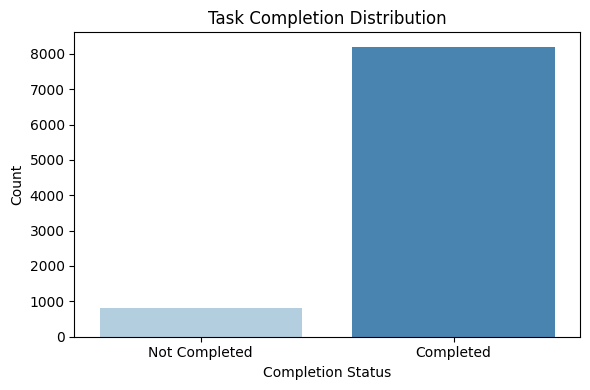

In [6]:
#Distribution of completed vs not completed
plt.figure(figsize=(6, 4))
sns.countplot(x="completed", data=df_long, hue="completed", palette="Blues", legend=False)
plt.title("Task Completion Distribution")
plt.xticks([0, 1], ["Not Completed", "Completed"])
plt.xlabel("Completion Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

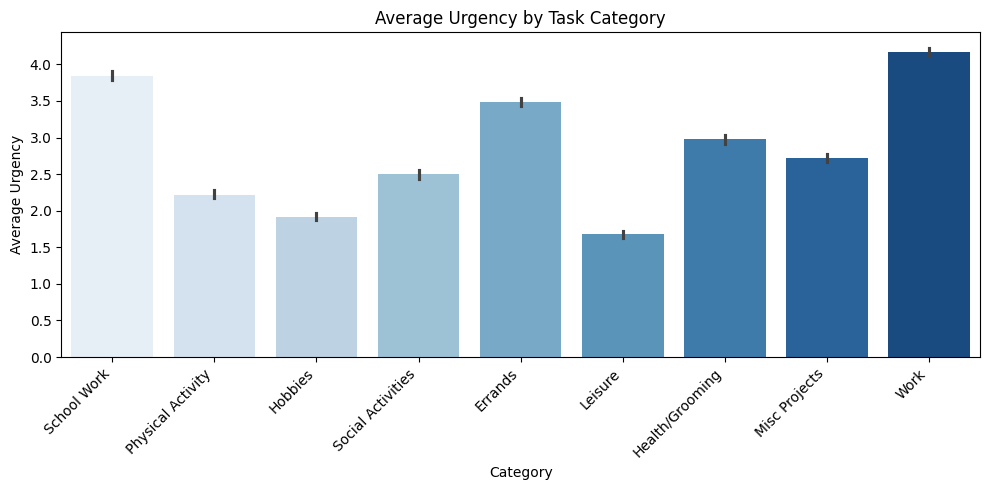

In [7]:
#Average urgency by task category
plt.figure(figsize=(10, 5))
category_names = {0: "School Work", 1: "Physical Activity", 2: "Hobbies",
                  3: "Social Activities", 4: "Errands", 5: "Leisure",
                  6: "Health/Grooming", 7: "Misc Projects", 8: "Work"}

df_long["category_name"] = df_long["category"].map(category_names)

sns.barplot(x="category_name", data=df_long, y="urgency", 
            hue="category_name", palette="Blues", legend=False)
plt.title("Average Urgency by Task Category")
plt.xlabel("Category")
plt.ylabel("Average Urgency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

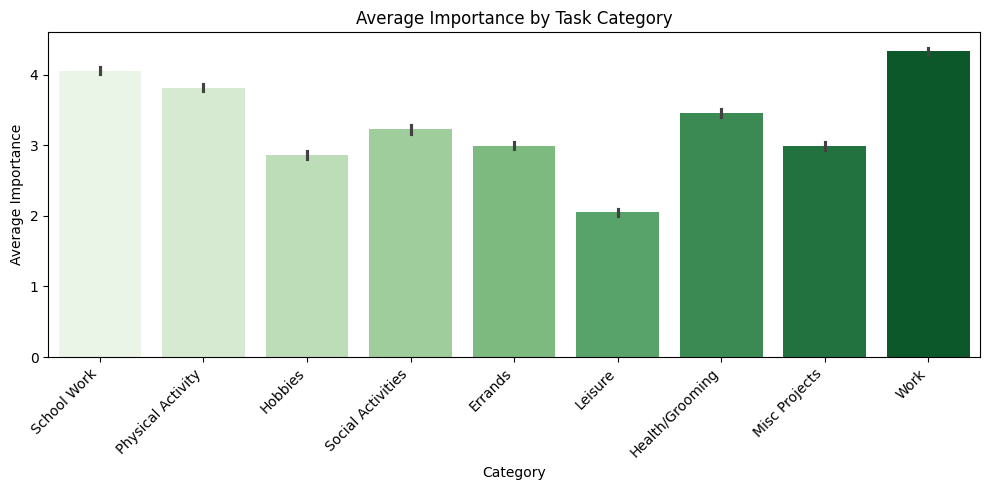

In [8]:
#Average importance by task category
plt.figure(figsize=(10, 5))
sns.barplot(x="category_name", data=df_long, y="importance",
            hue="category_name", palette="Greens", legend=False)
plt.title("Average Importance by Task Category")
plt.xlabel("Category")
plt.ylabel("Average Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

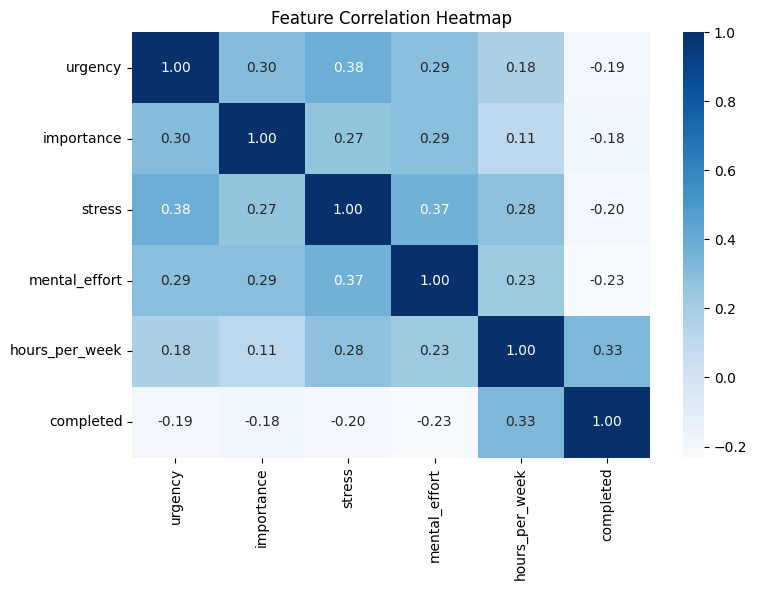

In [9]:
#Correlation heatmap
plt.figure(figsize=(8, 6))
features = ["urgency", "importance", "stress", "mental_effort", "hours_per_week", "completed"]
correlation_matrix = df_long[features].corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

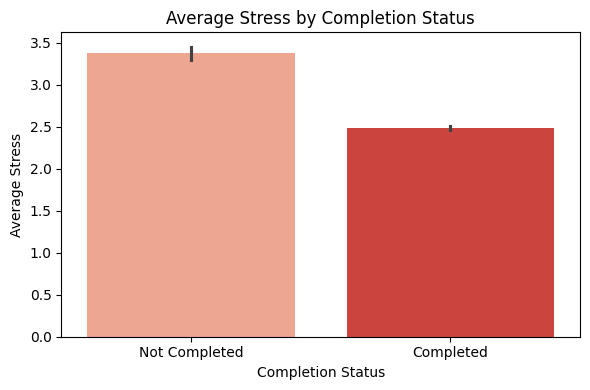

In [10]:
#Average stress by completion status
plt.figure(figsize=(6, 4))
sns.barplot(x="completed", data=df_long, y="stress",
            hue="completed", palette="Reds", legend=False)
plt.title("Average Stress by Completion Status")
plt.xticks([0, 1], ["Not Completed", "Completed"])
plt.xlabel("Completion Status")
plt.ylabel("Average Stress")
plt.tight_layout()
plt.show()